# Analisi delle vendite di cioccolato

In questo progetto analizziamo un dataset di vendite di prodotti al cioccolato.

Il lavoro si collega a una prima analisi esplorativa, in cui sono state osservate le principali caratteristiche del dataset.

In questa seconda parte, l’obiettivo è approfondire i dati per rispondere a quattro domande principali:

1. Cosa guida la revenue (fatturato)?
2. Qual è il canale di vendita più efficace?
3. Su quali prodotti conviene concentrarsi?
4. In quali mercati conviene espandersi?

L’obiettivo è trasformare i dati in informazioni utili per prendere decisioni.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway
import statsmodels.api as sm

sns.set()

df = pd.read_csv("df_cleaned_chocolate.csv")

df.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,total_cost,profit,product_name,brand,category,cocoa_percent,weight_g,store_name,city,country,store_type,age,gender,loyalty_member,join_date,margin_percentage,month,year
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56,Praline Chocolate 70%,Hershey,White,0.7,200,Chocolate Store 93,Sydney,Australia,Airport,44,Male,True,2021-11-17,30.26,1,2023
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97,Dark Chocolate 60%,Lindt,Praline,0.6,50,Chocolate Store 65,New York,USA,Retail,63,Female,True,2023-07-03,47.10,10,2023
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75,Milk Chocolate 90%,Hershey,Milk,0.9,50,Chocolate Store 78,London,UK,Airport,35,Male,True,2023-10-09,48.65,5,2023
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04,Dark Chocolate 60%,Godiva,Praline,0.6,50,Chocolate Store 88,Toronto,Canada,Retail,37,Female,True,2023-05-30,38.04,6,2024
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40,Truffle Chocolate 90%,Hershey,Truffle,0.9,120,Chocolate Store 54,London,UK,Online,57,Female,False,2021-08-20,35.66,9,2024


## Struttura del dataset

Vediamo com’è fatto il dataset:


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990236 entries, 0 to 990235
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   order_id           990236 non-null  object 
 1   order_date         990236 non-null  object 
 2   product_id         990236 non-null  object 
 3   store_id           990236 non-null  object 
 4   customer_id        990236 non-null  object 
 5   quantity           990236 non-null  int64  
 6   unit_price         990236 non-null  float64
 7   discount           990236 non-null  float64
 8   revenue            990236 non-null  float64
 9   total_cost         990236 non-null  float64
 10  profit             990236 non-null  float64
 11  product_name       990236 non-null  object 
 12  brand              990236 non-null  object 
 13  category           990236 non-null  object 
 14  cocoa_percent      990236 non-null  float64
 15  weight_g           990236 non-null  int64  
 16  st

In [22]:
df.describe()

,quantity,unit_price,discount,revenue,total_cost,profit,cocoa_percent,weight_g,age,margin_percentage,month,year
count,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000
mean,2.999760,9.002360,0.056242,25.487508,15.292310,10.195198,0.691481,107.431400,44.044334,39.997987,6.517089,2023.500423
std,1.413644,3.462932,0.076806,16.369318,9.973389,6.779464,0.145971,50.719617,15.330031,5.768733,3.449626,0.500000
min,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000,0.500000,50.000000,18.000000,29.820000,1.000000,2023.000000
25%,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000,0.500000,80.000000,31.000000,35.010000,4.000000,2023.000000
50%,3.000000,9.000000,0.000000,21.920000,13.030000,8.610000,0.700000,100.000000,44.000000,39.990000,7.000000,2024.000000
75%,4.000000,12.000000,0.150000,35.880000,21.420000,14.170000,0.800000,120.000000,57.000000,44.990000,10.000000,2024.000000
max,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000,0.900000,200.000000,70.000000,50.170000,12.000000,2024.000000


COSA GUIDA LA REVENUE?

## Relazioni tra variabili

Cerchiamo di capire quali variabili sono più legate alla revenue oseervando la correlazione tra revenue e le variabili quantity, unit price e discount

In [6]:
corr = df[['revenue','quantity','unit_price','discount']].corr()

corr['revenue'].sort_values(ascending=False)

revenue       1.000000
quantity      0.733963
unit_price    0.599265
discount     -0.127325
Name: revenue, dtype: float64

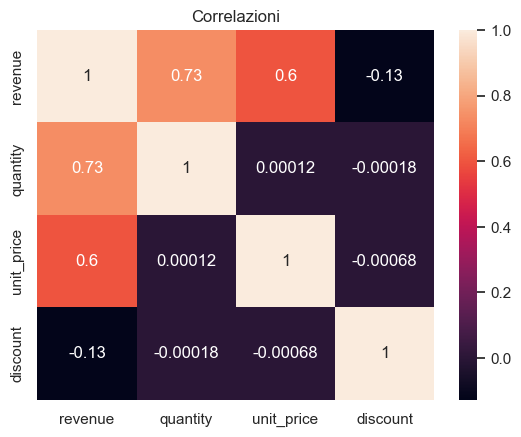

In [7]:
sns.heatmap(corr, annot=True)
plt.title("Correlazioni")
plt.show()

Abbiamo una relazione positiva forte con quantity e unit price, e una relazione quasi negativa con il discount, quindi lo sconto non ha un impatto significativo sul fatturato.
In conclusione più si alza il prezzo e le quantità vendute più aumenta il guadagno, mentre gli sconti abbassano il valore dell'ordine.

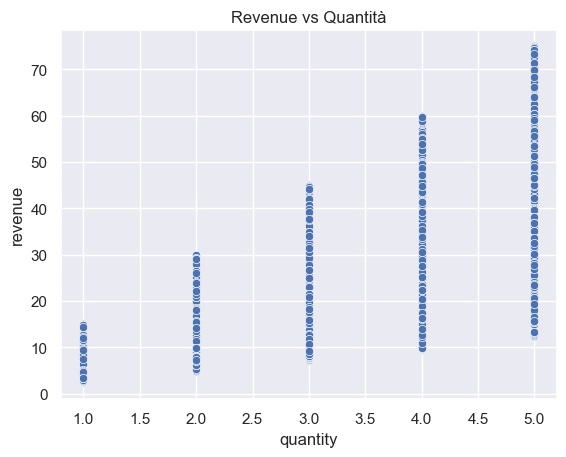

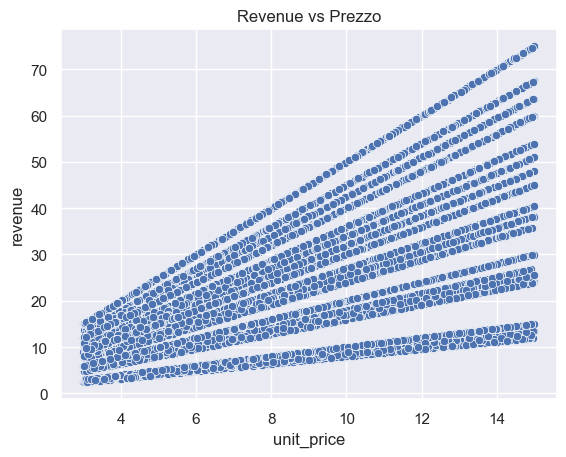

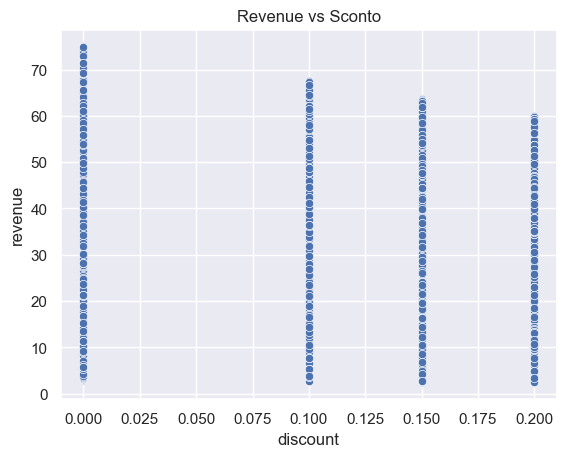

In [8]:
sns.scatterplot(x='quantity', y='revenue', data=df.sample(20000))
plt.title("Revenue vs Quantità")
plt.show()

sns.scatterplot(x='unit_price', y='revenue', data=df.sample(20000))
plt.title("Revenue vs Prezzo")
plt.show()

sns.scatterplot(x='discount', y='revenue', data=df.sample(20000))
plt.title("Revenue vs Sconto")
plt.show()

Aumentando la quantità e il prezzo unitario dei nostri prodotti comporta un aumento significativo del fatturato, invece lo sconto ha l'effetto opposto, più sconto viene applicato e più il fatturato diminuisce, pertanto deve essere usato con più attenzione.

## Regressione lineare

Usiamo un modello semplice per capire cosa influenza la revenue.

In [10]:
X = df[['quantity','unit_price','discount']]
y = df['revenue']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                 3.499e+06
Date:                Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:39:09   Log-Likelihood:            -2.9597e+06
No. Observations:              990236   AIC:                         5.919e+06
Df Residuals:                  990232   BIC:                         5.919e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -23.9783      0.017  -1387.693      0.0

La regressione spiega il 91% della variabilità della revenue e mostra che la revenue è guidata da quantità e prezzo, mentre gli sconti hanno un effetto negativo. Il P value è 0, quindi le variabili sono statisticamente significative e quindi affidabili. 

CANALE PIÙ EFFICACE?

## Confronto tra canali di vendita

Analizziamo i canali di vendita, confrontando il profitto medio e totale dei vari canali, per capire quale sia più efficace

In [11]:
df.groupby('store_type')['profit'].mean()

store_type
Airport    10.184252
Mall       10.194939
Online     10.203647
Retail     10.201633
Name: profit, dtype: float64

In [12]:
df.groupby('store_type')['profit'].sum()

store_type
Airport    3016616.30
Mall       2625013.34
Online     2529729.02
Retail     1924293.20
Name: profit, dtype: float64

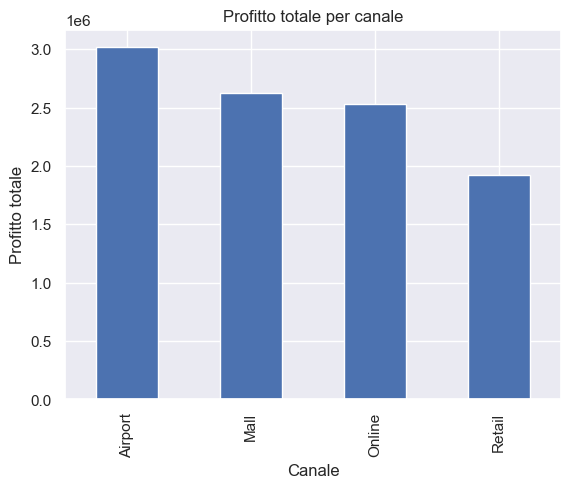

In [23]:
profit_canale= df.groupby("store_type")["profit"].sum()

profit_canale.plot(kind="bar")
plt.title("Profitto totale per canale")
plt.xlabel("Canale")
plt.ylabel("Profitto totale")
plt.show()

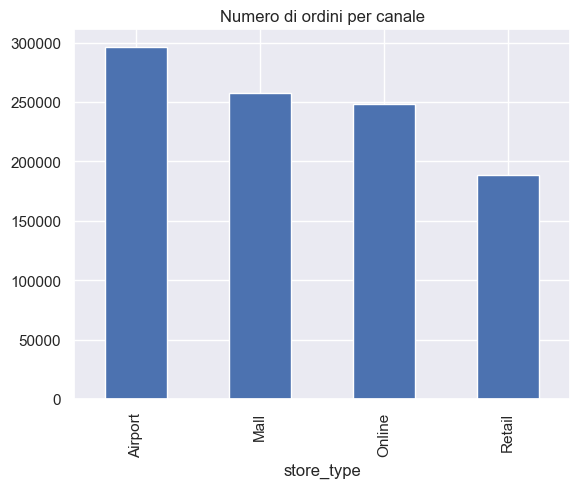

In [25]:
ordini= df.groupby("store_type")["order_id"].count()
ordini.plot(kind="bar")
plt.title("Numero di ordini per canale")
plt.show()

In [27]:
groups = [g['profit'].values for _, g in df.groupby('store_type')]

f_stat, p_value = f_oneway(*groups)

print("p-value:", p_value)

p-value: 0.7226127138190329


Anche se il profitto medio tra i vari canali è simile, alcuni canali generano più profitto  perchè hanno un volume di vendite maggiore, quindi la differenza non è nell'efficienza ma nel volume. Il test Anova mostra che non ci sono differenze significative sufficienti per affermare che i profitti medi differiscano tra i canali.

SU QUALI PRODOTTI PUNTARE?

In [15]:
prod = df.groupby('product_name')['profit'].sum().sort_values(ascending=False)

prod.head(10)

product_name
Dark Chocolate 50%       709743.41
Truffle Chocolate 80%    656762.54
Milk Chocolate 70%       553577.55
Praline Chocolate 50%    553128.68
Dark Chocolate 60%       508957.00
White Chocolate 50%      506724.61
White Chocolate 90%      455226.43
White Chocolate 80%      453805.73
Truffle Chocolate 90%    453042.19
Praline Chocolate 70%    451014.68
Name: profit, dtype: float64

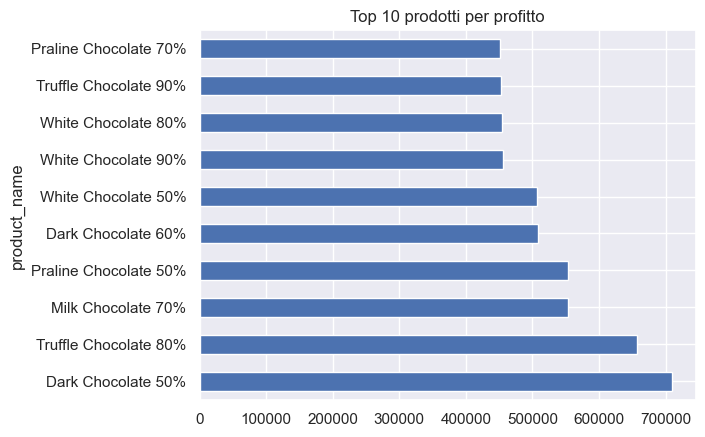

In [16]:
prod.head(10).plot(kind='barh')
plt.title("Top 10 prodotti per profitto")
plt.show()

In [17]:
df.groupby('product_name')['profit'].mean().sort_values(ascending=False).head(10)

product_name
Milk Chocolate 60%       10.252003
Dark Chocolate 70%       10.245322
Dark Chocolate 80%       10.236598
Praline Chocolate 50%    10.232512
Milk Chocolate 50%       10.231508
Milk Chocolate 70%       10.227383
Praline Chocolate 90%    10.218348
Dark Chocolate 60%       10.217353
White Chocolate 80%      10.208204
Truffle Chocolate 60%    10.206065
Name: profit, dtype: float64

DOVE ESPANDERSI?

In [18]:
country = df.groupby('country')['profit'].sum().sort_values(ascending=False)

country

country
Australia    2528226.33
Canada       1818884.04
UK           1608159.86
France       1604880.44
USA          1521495.26
Germany      1014005.93
Name: profit, dtype: float64

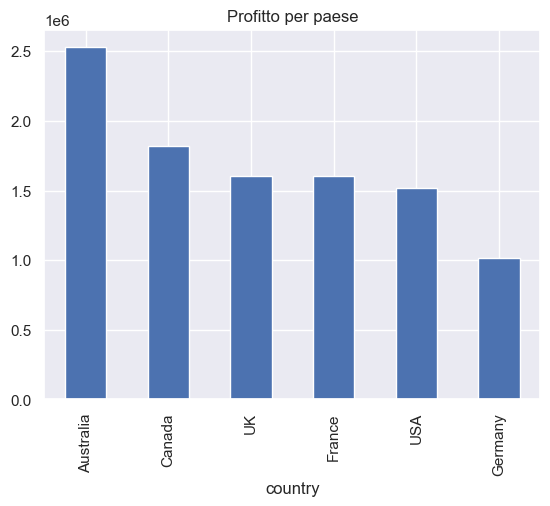

In [19]:
country.plot(kind='bar')
plt.title("Profitto per paese")
plt.show()

In [20]:
df.groupby('country')['profit'].mean()

country
Australia    10.205119
Canada       10.196967
France       10.157985
Germany      10.216581
UK           10.187447
USA          10.210007
Name: profit, dtype: float64